# 🐔 vs 🦆 Transfer Learning with CNN

This notebook demonstrates **Transfer Learning** using a pre-trained ResNet50 model to classify images of **chickens** vs **ducks**.

## Pipeline Overview
1. Download ~100 chicken images + ~100 duck images from the internet
2. Preprocess and organize the dataset
3. Fine-tune a pre-trained ResNet50 (trained on ImageNet)
4. Evaluate and generate a classification report

> **Runtime:** Make sure to enable GPU — `Runtime > Change runtime type > T4 GPU`

## Step 1: Install Dependencies

In [1]:
!pip install -q icrawler Pillow scikit-learn matplotlib seaborn

## Step 2: Import Libraries

In [2]:
import os
import shutil
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms, models
from torchvision.datasets import ImageFolder

from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


## Step 3: Download Images Using icrawler

We use `icrawler` with Google Images to download ~100 images per class.

In [3]:
from icrawler.builtin import GoogleImageCrawler, BingImageCrawler

DATA_DIR = Path('data')
RAW_DIR  = DATA_DIR / 'raw'

classes = {
    'chicken': ['chicken bird farm', 'hen chicken poultry', 'rooster chicken'],
    'duck':    ['duck bird pond',    'mallard duck water',  'domestic duck']
}

IMAGES_PER_QUERY = 40   # 3 queries × 40 = ~120 per class; duplicates get removed later

for label, queries in classes.items():
    save_dir = RAW_DIR / label
    save_dir.mkdir(parents=True, exist_ok=True)
    print(f'\nDownloading "{label}" images...')
    for query in queries:
        try:
            crawler = BingImageCrawler(
                storage={'root_dir': str(save_dir)},
                feeder_threads=1,
                parser_threads=1,
                downloader_threads=4
            )
            crawler.crawl(
                keyword=query,
                max_num=IMAGES_PER_QUERY,
                file_idx_offset='auto'
            )
        except Exception as e:
            print(f'  Query "{query}" failed: {e}')

# Count downloads
for label in classes:
    n = len(list((RAW_DIR / label).glob('*')))
    print(f'{label}: {n} files downloaded')

ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/thumbnails/039/637/658/small_2x/young-yellow-chickens-on-a-poultry-farm-indoors-chicken-farm-chicken-feeding-photo.jpg
ERROR:downloader:Response status code 403, file https://wallpapercrafter.com/desktop7/1824764-hen-hen-brahma-brown-nature-animals-image-animal.jpg
ERROR:downloader:Response status code 404, file https://www.shutterstock.com/shutterstock/videos/3713059057/thumb/1.jpg
ERROR:downloader:Response status code 404, file https://www.shutterstock.com/shutterstock/videos/3713058637/thumb/1.jpg
ERROR:downloader:Exception caught when downloading file https://img.freepik.com/premium-photo/chicken-bird-cage-poultry-farm_1048944-5600536.jpg, error: HTTPSConnectionPool(host='img.freepik.com', port=443): Read timed out. (read timeout=5), remaining retry times: 2


ERROR:downloader:Response status code 403, file https://suite101.com/wp-content/uploads/2024/08/duck-pond-ideas.jpg
ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/previews/047/371/962/non_2x/mallard-duck-on-the-water-photo.jpg
ERROR:downloader:Response status code 403, file https://preview.redd.it/uvuciakf94q61.jpg
ERROR:downloader:Exception caught when downloading file https://ogden_images.s3.amazonaws.com/www.iamcountryside.com/images/sites/3/2022/04/13143230/breed-profile-muscovy-duck.jpg, error: HTTPSConnectionPool(host='ogden_images.s3.amazonaws.com', port=443): Max retries exceeded with url: /www.iamcountryside.com/images/sites/3/2022/04/13143230/breed-profile-muscovy-duck.jpg (Caused by SSLError(SSLCertVerificationError(1, "[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: Hostname mismatch, certificate is not valid for 'ogden_images.s3.amazonaws.com'. (_ssl.c:1010)"))), remaining retry times: 2
ERROR:downloader:Exception c

chicken: 120 files downloaded
duck: 120 files downloaded


## Step 4: Clean & Validate Images

Remove corrupt files and non-images, then keep exactly 100 per class.

In [4]:
CLEAN_DIR   = DATA_DIR / 'clean'
IMAGES_PER_CLASS = 100

def is_valid_image(path):
    """Return True if the file is a readable RGB image."""
    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:
            img.convert('RGB')   # confirm convertible
        return True
    except Exception:
        return False

for label in classes:
    src   = RAW_DIR / label
    dst   = CLEAN_DIR / label
    dst.mkdir(parents=True, exist_ok=True)

    valid = [f for f in sorted(src.iterdir()) if is_valid_image(f)]
    random.shuffle(valid)
    kept  = valid[:IMAGES_PER_CLASS]

    for i, f in enumerate(kept):
        shutil.copy(f, dst / f'{label}_{i:04d}.jpg')

    print(f'{label}: {len(valid)} valid → keeping {len(kept)}')

chicken: 120 valid → keeping 100
duck: 120 valid → keeping 100


## Step 5: Train / Val / Test Split

Split: **70% train | 15% val | 15% test** (stratified by class)

In [5]:
SPLIT_DIR  = DATA_DIR / 'split'
SPLITS     = {'train': 0.70, 'val': 0.15, 'test': 0.15}

for split in SPLITS:
    for label in classes:
        (SPLIT_DIR / split / label).mkdir(parents=True, exist_ok=True)

for label in classes:
    files = sorted((CLEAN_DIR / label).iterdir())
    random.shuffle(files)
    n  = len(files)
    n_train = int(n * SPLITS['train'])
    n_val   = int(n * SPLITS['val'])

    buckets = {
        'train': files[:n_train],
        'val':   files[n_train:n_train + n_val],
        'test':  files[n_train + n_val:]
    }
    for split, flist in buckets.items():
        for f in flist:
            shutil.copy(f, SPLIT_DIR / split / label / f.name)
        print(f'{split}/{label}: {len(flist)} images')

train/chicken: 70 images
val/chicken: 15 images
test/chicken: 15 images
train/duck: 70 images
val/duck: 15 images
test/duck: 15 images


## Step 6: Data Augmentation & DataLoaders

In [6]:
# ImageNet statistics (used by all torchvision pre-trained models)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_SIZE      = 224
BATCH_SIZE    = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

train_ds = ImageFolder(str(SPLIT_DIR / 'train'), transform=train_transform)
val_ds   = ImageFolder(str(SPLIT_DIR / 'val'),   transform=val_test_transform)
test_ds  = ImageFolder(str(SPLIT_DIR / 'test'),  transform=val_test_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

class_names = train_ds.classes
print(f'Classes: {class_names}')
print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Classes: ['chicken', 'duck']
Train: 140 | Val: 30 | Test: 30


## Step 7: Visualise Sample Images

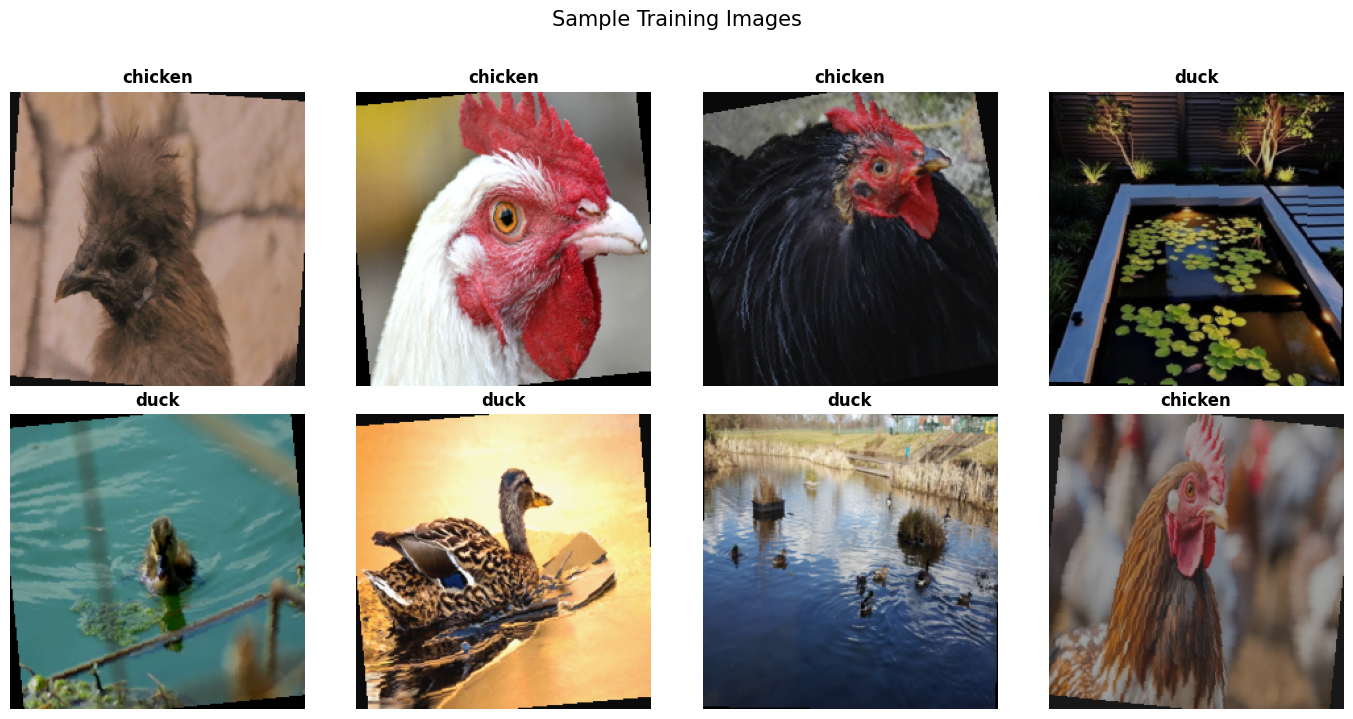

In [7]:
def imshow_grid(loader, class_names, n=8):
    images, labels = next(iter(loader))
    images = images[:n]
    labels = labels[:n]

    # Un-normalise for display
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD ).view(3,1,1)
    imgs = (images * std + mean).clamp(0, 1)

    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    for ax, img, lbl in zip(axes.flat, imgs, labels):
        ax.imshow(img.permute(1, 2, 0).numpy())
        ax.set_title(class_names[lbl], fontsize=12, fontweight='bold')
        ax.axis('off')
    plt.suptitle('Sample Training Images', fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()

imshow_grid(train_loader, class_names)

## Step 8: Build the Transfer Learning Model

We use **ResNet50** pre-trained on ImageNet. The strategy:
- **Phase 1 (Feature Extraction):** Freeze all backbone layers; only train the new classifier head.
- **Phase 2 (Fine-Tuning):** Unfreeze the last residual block + head; train with a smaller LR.

In [8]:
def build_model(num_classes=2, freeze_backbone=True):
    # Load pre-trained ResNet50
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace the final fully-connected layer
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_classes)
    )
    return model

model = build_model(num_classes=2, freeze_backbone=True).to(device)

# Count trainable params
total   = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params:     {total:,}')
print(f'Trainable params: {trainable:,}  ({100*trainable/total:.1f}%)')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 108MB/s]


Total params:     24,033,090
Trainable params: 525,058  (2.2%)


## Step 9: Training Utilities

In [9]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds      = outputs.max(1)
        correct      += (preds == labels).sum().item()
        total        += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss    = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        _, preds      = outputs.max(1)
        correct      += (preds == labels).sum().item()
        total        += labels.size(0)
    return running_loss / total, correct / total


def run_training(model, train_loader, val_loader,
                 epochs, lr, weight_decay=1e-4,
                 label='Phase'):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc, best_state = 0.0, None

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc' ].append(tr_acc)
        history['val_loss'  ].append(vl_loss)
        history['val_acc'   ].append(vl_acc)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(f'[{label}] Epoch {epoch:02d}/{epochs} | '
              f'Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | '
              f'Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}')

    # Restore best weights
    model.load_state_dict(best_state)
    print(f'\nBest val accuracy ({label}): {best_val_acc:.4f}')
    return history

## Step 10: Phase 1 — Feature Extraction (Frozen Backbone)

In [10]:
history_p1 = run_training(
    model, train_loader, val_loader,
    epochs=10, lr=1e-3,
    label='Phase-1 (frozen)'
)

[Phase-1 (frozen)] Epoch 01/10 | Train Loss: 0.6090  Acc: 0.7286 | Val Loss: 0.4592  Acc: 0.9667
[Phase-1 (frozen)] Epoch 02/10 | Train Loss: 0.3315  Acc: 0.9500 | Val Loss: 0.2416  Acc: 0.9667
[Phase-1 (frozen)] Epoch 03/10 | Train Loss: 0.1633  Acc: 0.9571 | Val Loss: 0.1676  Acc: 0.9333
[Phase-1 (frozen)] Epoch 04/10 | Train Loss: 0.1107  Acc: 0.9643 | Val Loss: 0.1078  Acc: 0.9667
[Phase-1 (frozen)] Epoch 05/10 | Train Loss: 0.0643  Acc: 0.9929 | Val Loss: 0.0971  Acc: 0.9667
[Phase-1 (frozen)] Epoch 06/10 | Train Loss: 0.0569  Acc: 0.9929 | Val Loss: 0.0902  Acc: 0.9667
[Phase-1 (frozen)] Epoch 07/10 | Train Loss: 0.0665  Acc: 0.9786 | Val Loss: 0.0907  Acc: 0.9667
[Phase-1 (frozen)] Epoch 08/10 | Train Loss: 0.0489  Acc: 0.9929 | Val Loss: 0.0859  Acc: 0.9667
[Phase-1 (frozen)] Epoch 09/10 | Train Loss: 0.0508  Acc: 0.9929 | Val Loss: 0.0872  Acc: 0.9667
[Phase-1 (frozen)] Epoch 10/10 | Train Loss: 0.0358  Acc: 0.9929 | Val Loss: 0.0884  Acc: 0.9667

Best val accuracy (Phase-1 (f

## Step 11: Phase 2 — Fine-Tuning (Unfreeze Last Block)

In [11]:
# Unfreeze the last residual block (layer4) + the new head
for name, param in model.named_parameters():
    if 'layer4' in name or 'fc' in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params after unfreezing layer4: {trainable:,}')

history_p2 = run_training(
    model, train_loader, val_loader,
    epochs=10, lr=1e-4,        # much smaller LR for fine-tuning
    weight_decay=1e-4,
    label='Phase-2 (fine-tune)'
)

Trainable params after unfreezing layer4: 15,489,794
[Phase-2 (fine-tune)] Epoch 01/10 | Train Loss: 0.3627  Acc: 0.9429 | Val Loss: 0.2998  Acc: 0.9667
[Phase-2 (fine-tune)] Epoch 02/10 | Train Loss: 0.2246  Acc: 0.9786 | Val Loss: 0.1664  Acc: 0.9667
[Phase-2 (fine-tune)] Epoch 03/10 | Train Loss: 0.1345  Acc: 0.9929 | Val Loss: 0.0996  Acc: 0.9667
[Phase-2 (fine-tune)] Epoch 04/10 | Train Loss: 0.1060  Acc: 0.9857 | Val Loss: 0.0911  Acc: 0.9667
[Phase-2 (fine-tune)] Epoch 05/10 | Train Loss: 0.0544  Acc: 1.0000 | Val Loss: 0.0768  Acc: 0.9667
[Phase-2 (fine-tune)] Epoch 06/10 | Train Loss: 0.0442  Acc: 1.0000 | Val Loss: 0.0697  Acc: 0.9667
[Phase-2 (fine-tune)] Epoch 07/10 | Train Loss: 0.0294  Acc: 1.0000 | Val Loss: 0.0682  Acc: 0.9667
[Phase-2 (fine-tune)] Epoch 08/10 | Train Loss: 0.0253  Acc: 1.0000 | Val Loss: 0.0629  Acc: 0.9667
[Phase-2 (fine-tune)] Epoch 09/10 | Train Loss: 0.0342  Acc: 1.0000 | Val Loss: 0.0622  Acc: 0.9667
[Phase-2 (fine-tune)] Epoch 10/10 | Train Loss:

## Step 12: Plot Training Curves

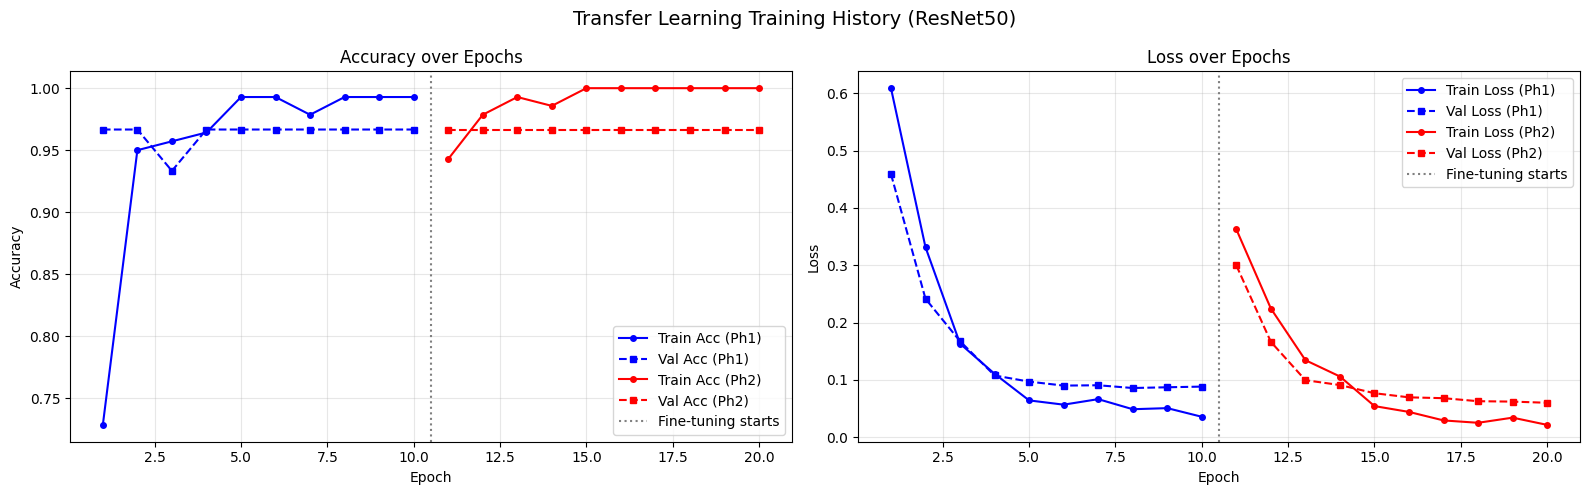

In [12]:
def plot_history(h1, h2):
    epochs_p1 = range(1, len(h1['train_acc']) + 1)
    offset    = len(h1['train_acc'])
    epochs_p2 = range(offset + 1, offset + len(h2['train_acc']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # ---- Accuracy ----
    ax1.plot(epochs_p1, h1['train_acc'], 'b-o', ms=4, label='Train Acc (Ph1)')
    ax1.plot(epochs_p1, h1['val_acc'],   'b--s', ms=4, label='Val Acc (Ph1)')
    ax1.plot(epochs_p2, h2['train_acc'], 'r-o', ms=4, label='Train Acc (Ph2)')
    ax1.plot(epochs_p2, h2['val_acc'],   'r--s', ms=4, label='Val Acc (Ph2)')
    ax1.axvline(offset + 0.5, color='gray', linestyle=':', label='Fine-tuning starts')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.set_title('Accuracy over Epochs'); ax1.legend(); ax1.grid(alpha=0.3)

    # ---- Loss ----
    ax2.plot(epochs_p1, h1['train_loss'], 'b-o', ms=4, label='Train Loss (Ph1)')
    ax2.plot(epochs_p1, h1['val_loss'],   'b--s', ms=4, label='Val Loss (Ph1)')
    ax2.plot(epochs_p2, h2['train_loss'], 'r-o', ms=4, label='Train Loss (Ph2)')
    ax2.plot(epochs_p2, h2['val_loss'],   'r--s', ms=4, label='Val Loss (Ph2)')
    ax2.axvline(offset + 0.5, color='gray', linestyle=':', label='Fine-tuning starts')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.set_title('Loss over Epochs'); ax2.legend(); ax2.grid(alpha=0.3)

    plt.suptitle('Transfer Learning Training History (ResNet50)', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_history(history_p1, history_p2)

## Step 13: Evaluate on Test Set & Classification Report

In [13]:
@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    for images, labels in loader:
        images = images.to(device)
        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1).cpu()
        preds   = probs.argmax(dim=1)
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

y_true, y_pred, y_probs = get_predictions(model, test_loader)

print('=' * 55)
print('          CLASSIFICATION REPORT (Test Set)')
print('=' * 55)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

          CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

     chicken     0.9286    0.8667    0.8966        15
        duck     0.8750    0.9333    0.9032        15

    accuracy                         0.9000        30
   macro avg     0.9018    0.9000    0.8999        30
weighted avg     0.9018    0.9000    0.8999        30



## Step 14: Confusion Matrix

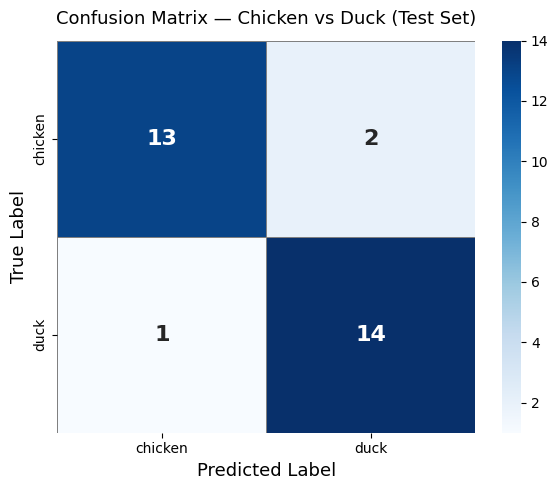

Test Accuracy: 0.9000 (90.00%)


In [14]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    linewidths=0.5, linecolor='gray',
    annot_kws={'size': 16, 'weight': 'bold'}
)
ax.set_xlabel('Predicted Label', fontsize=13)
ax.set_ylabel('True Label', fontsize=13)
ax.set_title('Confusion Matrix — Chicken vs Duck (Test Set)', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

test_acc = (y_true == y_pred).mean()
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')

## Step 15: Visualise Predictions on Test Samples

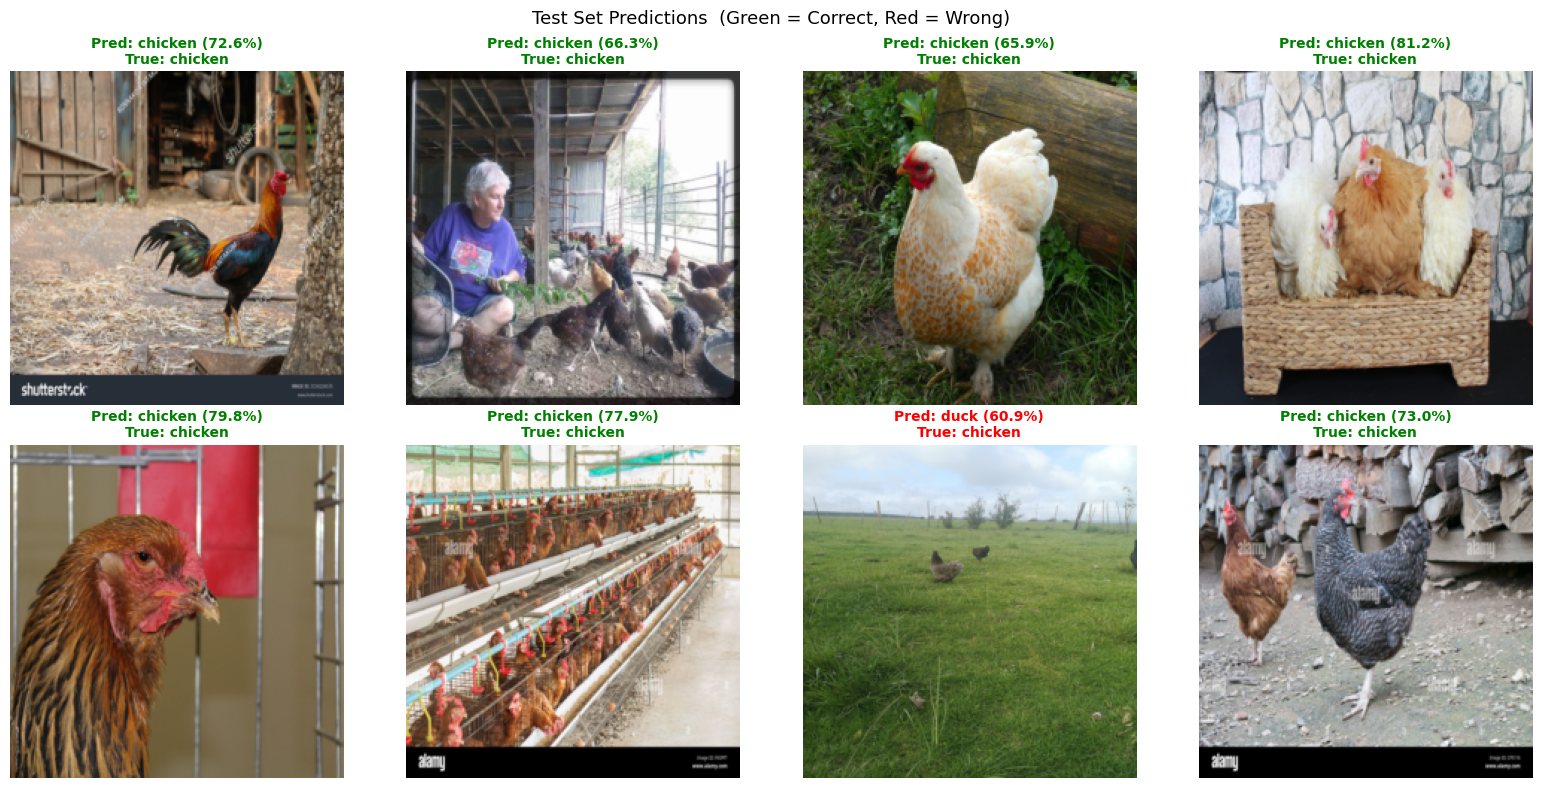

In [15]:
@torch.no_grad()
def visualise_predictions(model, loader, class_names, n=8):
    model.eval()
    images_shown, preds_shown, labels_shown, probs_shown = [], [], [], []

    for images, labels in loader:
        outputs = model(images.to(device))
        probs   = torch.softmax(outputs, dim=1).cpu()
        preds   = probs.argmax(1)
        images_shown.extend(images)
        preds_shown.extend(preds.numpy())
        labels_shown.extend(labels.numpy())
        probs_shown.extend(probs.numpy())
        if len(images_shown) >= n:
            break

    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD ).view(3,1,1)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for i, ax in enumerate(axes.flat):
        img   = (images_shown[i] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
        pred  = preds_shown[i]
        true  = labels_shown[i]
        conf  = probs_shown[i][pred] * 100
        color = 'green' if pred == true else 'red'
        ax.imshow(img)
        ax.set_title(
            f'Pred: {class_names[pred]} ({conf:.1f}%)\nTrue: {class_names[true]}',
            color=color, fontsize=10, fontweight='bold'
        )
        ax.axis('off')
    plt.suptitle('Test Set Predictions  (Green = Correct, Red = Wrong)', fontsize=13)
    plt.tight_layout()
    plt.show()

visualise_predictions(model, test_loader, class_names)

## Step 16: Save the Model

In [16]:
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names':      class_names,
    'img_size':         IMG_SIZE,
    'architecture':     'resnet50'
}, 'chicken_vs_duck_resnet50.pt')

print('Model saved to chicken_vs_duck_resnet50.pt')

Model saved to chicken_vs_duck_resnet50.pt


## Step 17: Inference on a Single Image

Running inference on: data/split/test/chicken/chicken_0091.jpg
Prediction : chicken  (70.56% confidence)
  chicken   : 70.56%
  duck      : 29.44%


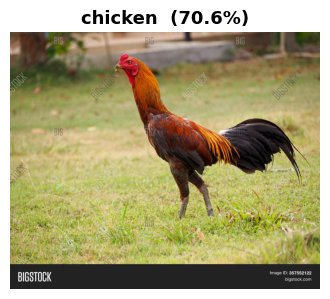

In [17]:
@torch.no_grad()
def predict_single(image_path, model, class_names):
    """
    Predict the class of a single image.
    image_path : str or Path to the image file
    """
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ])
    img   = Image.open(image_path).convert('RGB')
    x     = transform(img).unsqueeze(0).to(device)
    model.eval()
    probs = torch.softmax(model(x), dim=1).cpu().numpy()[0]
    pred  = probs.argmax()

    print(f'Prediction : {class_names[pred]}  ({probs[pred]*100:.2f}% confidence)')
    for i, c in enumerate(class_names):
        print(f'  {c:10s}: {probs[i]*100:.2f}%')

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f'{class_names[pred]}  ({probs[pred]*100:.1f}%)', fontsize=13, fontweight='bold')
    plt.axis('off')
    plt.show()

# ---- Example usage ----
# Pick any test image automatically for demonstration
sample_path = next((SPLIT_DIR / 'test').rglob('*.jpg'))
print(f'Running inference on: {sample_path}')
predict_single(sample_path, model, class_names)